MSE 446 Project - Team 2

In [142]:
import pandas as pd


In [143]:
# Read song datasets
songs_popular = pd.read_csv('datasets/high_popularity_spotify_data.csv')
songs_notpopular = pd.read_csv('datasets/low_popularity_spotify_data.csv')

# artist popularity dataset
artist_popularity = pd.read_csv('datasets/spotify_data_artists.csv')

# combine low popularity and high popularity songs into one dataset
songs = pd.concat([songs_popular, songs_notpopular], ignore_index=True)



In [144]:

# Prepare artist dataset
artist_popularity = artist_popularity.rename(columns={
    'name': 'artist_name',
    'popularity': 'artist_popularity'
})

# Normalize artist names
artist_popularity['artist_name'] = artist_popularity['artist_name'].str.lower().str.strip()

# Create lookup dictionary
artist_top_track_popularity = dict(zip(
    artist_popularity['artist_name'],
    artist_popularity['artist_popularity']
))

# Function to find first matching artist
def get_artist_popularity(artist_string):
    if pd.isna(artist_string):
        return None
    
    artists = [a.strip().lower() for a in artist_string.split(',')]
    
    for artist in artists:
        if artist in artist_top_track_popularity:
            return artist_top_track_popularity[artist]
    
    return None  # no match found

# Apply function to get the artist popularity from the second dataset
songs['artist_popularity'] = songs['track_artist'].apply(get_artist_popularity)

In [145]:
# Build artist -> max track popularity dictionary
artist_top_track_popularity = {}

for _, row in songs.iterrows():
    artists = [a.strip() for a in row["track_artist"].split(",")]
    
    for artist in artists:
        current_pop = row["track_popularity"]
        
        if artist not in artist_top_track_popularity:
            artist_top_track_popularity[artist] = current_pop
        else:
            artist_top_track_popularity[artist] = max(artist_top_track_popularity[artist], current_pop)

print(artist_top_track_popularity)


# Step 2: Function to get the top popularity among the artists of a song
def get_top_popularity(artists):
    artist_list = [a.strip() for a in artists.split(",")]
    pops = [artist_top_track_popularity.get(a, 0) for a in artist_list]
    return max(pops)


# Step 3: Apply to dataframe
songs["artist_top_track_popularity"] = songs["track_artist"].apply(get_top_popularity)

{'Lady Gaga': 100, 'Bruno Mars': 100, 'Billie Eilish': 97, 'Gracie Abrams': 93, 'Sabrina Carpenter': 93, 'ROSÉ': 98, 'Chappell Roan': 94, 'Addison Rae': 88, 'Gigi Perez': 93, 'The Weeknd': 92, 'Playboi Carti': 92, 'Charli xcx': 85, 'Tate McRae': 79, 'Shaboozey': 86, 'LISA': 85, 'Morgan Wallen': 86, 'Adam Port': 86, 'Stryv': 86, 'Keinemusik': 86, 'Orso': 86, 'Malachiii': 86, 'Tyler': 90, 'The Creator': 90, 'GloRilla': 88, 'Sexyy Red': 88, 'Lil Wayne': 88, 'JENNIE': 89, 'Rauw Alejandro': 82, 'Bad Bunny': 84, 'Don Toliver': 85, 'Post Malone': 84, 'Hozier': 84, 'The Marías': 84, 'Oscar Maydon': 93, 'Fuerza Regida': 93, 'Myles Smith': 88, 'Ariana Grande': 86, 'Benson Boone': 89, 'Myke Towers': 84, 'benny blanco': 84, 'KATSEYE': 85, 'Teddy Swims': 89, 'Mark Ambor': 82, 'KAROL G': 93, 'Djo': 89, 'Taylor Swift': 84, 'Omar Courtz': 89, 'De La Rose': 89, 'Kendrick Lamar': 88, 'Jin': 85, 'Feid': 88, 'DFZM': 84, 'Ovy On The Drums': 84, 'J Balvin': 84, 'Maluma': 84, 'Ryan Castro': 84, 'Blessd': 84,

In [146]:
songs.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,artist_popularity,artist_top_track_popularity
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,100,https://api.spotify.com/v1/tracks/2plbrEY59Iik...,spotify:track:2plbrEY59IikOBgBGLjaoe,Die With A Smile,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/2plb...,2plbrEY59IikOBgBGLjaoe,Die With A Smile,2024-08-16,0.0000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,88.0,100
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,97,https://api.spotify.com/v1/tracks/6dOtVTDdiauQ...,spotify:track:6dOtVTDdiauQNBQEDOtlAB,HIT ME HARD AND SOFT,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/6dOt...,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,2024-05-17,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,90.0,97
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,93,https://api.spotify.com/v1/tracks/7ne4VBA60CxG...,spotify:track:7ne4VBA60CxGM75vw0EYad,The Secret of Us (Deluxe),Today's Top Hits,https://api.spotify.com/v1/audio-analysis/7ne4...,7ne4VBA60CxGM75vw0EYad,That’s So True,2024-10-18,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,82.0,93
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,81,https://api.spotify.com/v1/tracks/1d7Ptw3qYcfp...,spotify:track:1d7Ptw3qYcfpdLNL5REhtJ,Short n' Sweet,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/1d7P...,1d7Ptw3qYcfpdLNL5REhtJ,Taste,2024-08-23,0.0000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,91.0,93
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,98,https://api.spotify.com/v1/tracks/5vNRhkKd0yEA...,spotify:track:5vNRhkKd0yEAg8suGBpjeY,APT.,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/5vNR...,5vNRhkKd0yEAg8suGBpjeY,APT.,2024-10-18,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,78.0,100


In [147]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   energy                       4830 non-null   float64
 1   tempo                        4830 non-null   float64
 2   danceability                 4830 non-null   float64
 3   playlist_genre               4831 non-null   object 
 4   loudness                     4830 non-null   float64
 5   liveness                     4830 non-null   float64
 6   valence                      4830 non-null   float64
 7   track_artist                 4831 non-null   object 
 8   time_signature               4830 non-null   float64
 9   speechiness                  4830 non-null   float64
 10  track_popularity             4831 non-null   int64  
 11  track_href                   4830 non-null   object 
 12  uri                          4830 non-null   object 
 13  track_album_name  

Max: 100.0
Min: 0.0


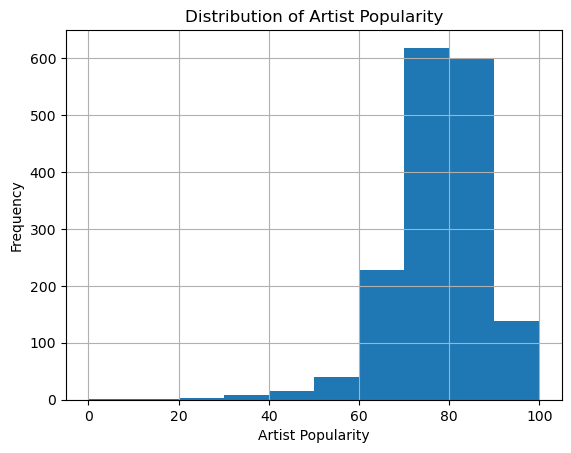

In [148]:
max_val = songs['artist_popularity'].max()
min_val = songs['artist_popularity'].min()

print("Max:", max_val)
print("Min:", min_val)

import matplotlib.pyplot as plt

songs['artist_popularity'].hist()
plt.xlabel('Artist Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist Popularity')
plt.show()

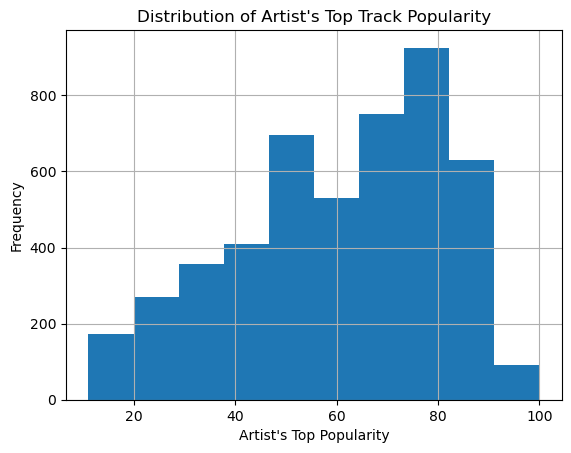

In [149]:
songs['artist_top_track_popularity'].hist()
plt.xlabel('Artist\'s Top Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist\'s Top Track Popularity')
plt.show()

In [150]:
## Clean data
pd.set_option('display.max_columns', None)

# Count of duplicated rows
songs.duplicated().sum()

# Drop duplicated rows
songs.drop_duplicates()

# Duplicated tracks
songs['track_id'].duplicated()

# We can see that there are duplicate tracks with identical rows except the playlist subgenre. 
songs[songs['track_id'].duplicated(keep=False)].sort_values('track_id')
dupes = songs[songs['track_id'].duplicated(keep=False)]
dupes.groupby('track_id').nunique()

diff_cols = dupes.groupby('track_id').nunique()
diff_cols.loc[:, (diff_cols > 1).any()]

# Here we can see that the only columns that differ are playlist_genre, playlist_name, playlist_subgenre, playlist_id. We will combine them 
# to deal with the duplicated song ids. 
cols_to_combine = [
    'playlist_genre',
    'playlist_name',
    'playlist_subgenre',
    'playlist_id'
]

agg_dict = {col: lambda x: ', '.join(sorted(set(x))) for col in cols_to_combine}

# keep other columns
for col in songs.columns:
    if col not in cols_to_combine and col != 'track_id':
        agg_dict[col] = 'first'

songs = songs.groupby('track_id', as_index=False).agg(agg_dict)


# '''valence
# track_artist
# time_signature
# speechiness
# track_popularity
# track_href'''

# songs['valence']


In [151]:
## Deal with missing values
songs.isna().sum().sort_values(ascending=False)


# We are aware of the missing artist popularity. We will replace these with 0s.
songs.isna().sum().sort_values(ascending=False)

#The others each have only one row so we will drop it. 
songs = songs.dropna()

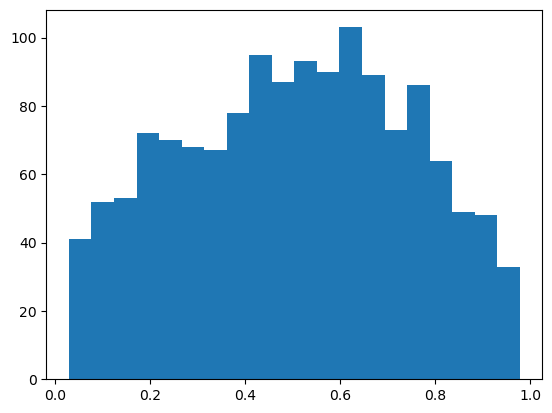

In [152]:
# Clean these columns # 
# valence
# track_artist
# time_signature
# speechiness
# track_popularity
# track_href'''

# Valence 
# We can see no outliers and is already scaled between 0 and 1. No prep needed. 
plt.hist(songs['valence'], bins=20)
plt.show()

# Track Artist - Not information needed for the model. Model should be blind to track artist - no dataprep needed




In [153]:
# Time signature
# 4 unique values - treat as categorical, one hot encode
songs['time_signature'].nunique()

songs['time_signature'] = songs['time_signature'].astype('category')

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(songs[['time_signature']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['time_signature']))
songs = pd.concat([songs, encoded_df], axis=1)

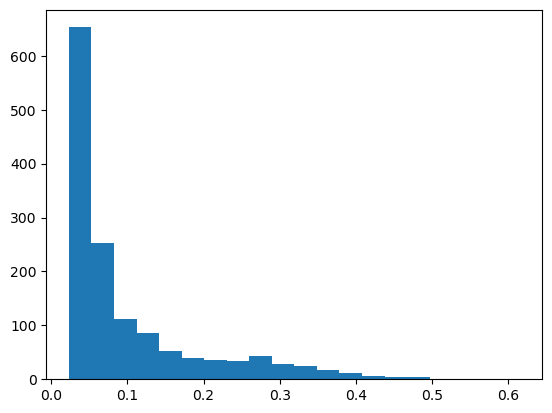

In [154]:
# speechiness
plt.hist(songs['speechiness'], bins=20)
plt.show()

# Can see that most data is close to 0, with long tail and max around 0.6. 
# Use MinMax Scaler to put on 0-1 scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
songs['speechiness'] = scaler.fit_transform(songs[['speechiness']])

In [158]:
# track_href
songs['track_href']
## This is a url column linking to spotify's API. It is not needed and can be dropped
songs = songs.drop('track_href', axis=1)



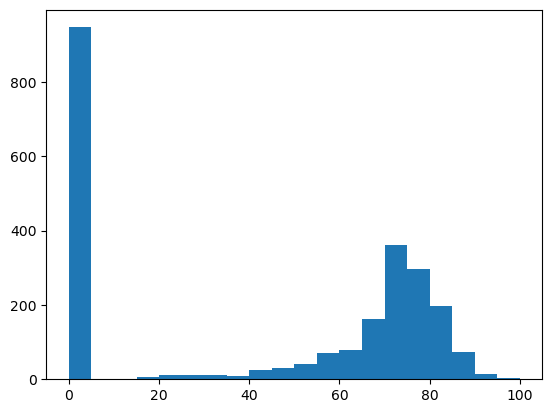

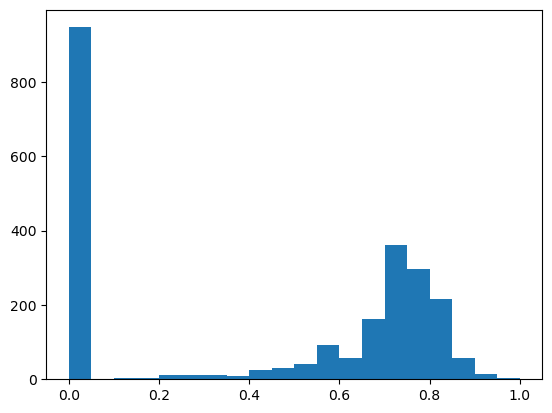

In [166]:
# track_popularity
songs['track_popularity'].isna().sum()

# fill with 0s to represnt missing/unknown. The model will be blind to popularity during training so missing values are not important. 
songs['track_popularity'] = songs['track_popularity'].fillna(0)
songs['track_popularity'].isna().sum()

plt.hist(songs['track_popularity'], bins=20)
plt.show()

# Use MinMaxScaler to scale 
scaler = MinMaxScaler()
songs['track_popularity'] = scaler.fit_transform(songs[['track_popularity']])

plt.hist(songs['track_popularity'], bins=20)
plt.show()

